# MNIST DNN 실험 — 가중치 초기화 / 정규화 / Dropout 비교

MNIST 숫자 이미지를 Dense 레이어만으로 구성된 DNN(Flatten → Dense(300) → Dense(100) → Dense(10))으로 분류하면서,
학습에 영향을 주는 세 가지 요소를 각각 바꿔가며 80 epoch씩 비교 실험한 노트북.

- **Dataset**: `tf.keras.datasets.mnist` (손글씨 숫자 0~9, 28x28 흑백 이미지). train/test를 합친 뒤 8:2로 다시 분할해서 사용
- **실험 1**: 가중치 초기화 — Random Normal vs Xavier(Glorot) Normal
- **실험 2**: 입력 정규화 — 0~255 원본 픽셀값 vs 0~1로 정규화한 값
- **실험 3**: Dropout 적용 여부
- 모든 실험은 `sgd` optimizer, `sparse_categorical_crossentropy` loss, 80 epoch로 동일한 조건에서 진행했고, `TensorBoard` 콜백으로 학습 로그를 기록함.


## 0. 공통 함수 정의
데이터 로드, 정규화/비정규화, 모델 생성, 평가까지 실험마다 재사용하는 함수들을 먼저 정의한다. `makemodel`의 `init_way`, `dropout` 매개변수를 바꿔가며 아래 세 실험에서 재사용한다.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def load_data():
    """MNIST 전체(원래 train+test 7만 장)를 다시 합친 뒤 8:2로 나눠 사용한다."""
    (X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    X = np.concatenate((X_train_full, X_test), axis=0)
    y = np.concatenate((y_train_full, y_test), axis=0)
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2)

    return X_train_full, y_train_full, X_test, y_test


def data_normalization(X_train_full, y_train_full, X_test):
    """픽셀값을 0~1 범위로 정규화하고, 학습 데이터 중 5000장을 검증셋으로 뗀다."""
    X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
    y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
    X_test = X_test / 255.0
    return X_valid, X_train, y_valid, y_train, X_test


def data_denormalization(X_train_full, y_train_full, X_test):
    """정규화를 거치지 않고 0~255 픽셀값을 그대로 사용 (비교 실험용)."""
    X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
    y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
    return X_valid, X_train, y_valid, y_train, X_test


def makemodel(X_train, y_train, X_valid, y_valid, epochs, init_way, dropout):
    """Flatten + Dense(300) + Dense(100) + Dense(10) 구조의 DNN.
    init_way: 'none' | 'random_normal' | 'xavier' 로 가중치 초기화 방식을 바꿔가며 실험한다.
    dropout: 'yes'면 출력층 뒤에 Dropout을 추가한다."""
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[28, 28]))

    if init_way == 'none':
        model.add(keras.layers.Dense(300, activation="relu"))
        model.add(keras.layers.Dense(100, activation="relu"))
        model.add(keras.layers.Dense(10, activation="softmax"))

    if init_way == 'random_normal':
        model.add(keras.layers.Dense(300, kernel_initializer='RandomNormal', activation="relu"))
        model.add(keras.layers.Dense(100, kernel_initializer='RandomNormal', activation="relu"))
        model.add(keras.layers.Dense(10, kernel_initializer='RandomNormal', activation="softmax"))

    if init_way == 'xavier':
        model.add(keras.layers.Dense(300, kernel_initializer='GlorotNormal', activation="relu"))  # Xavier Normal
        model.add(keras.layers.Dense(100, kernel_initializer='GlorotNormal', activation="relu"))
        model.add(keras.layers.Dense(10, kernel_initializer='GlorotNormal', activation="softmax"))

    if dropout == 'yes':
        model.add(keras.layers.Dropout(0.005))

    model.summary()

    model.compile(loss="sparse_categorical_crossentropy",
                optimizer="sgd",
                metrics=["accuracy"])

    # TensorBoard로 학습 로그 기록 (loss/accuracy 추이를 TensorBoard에서 시각적으로 확인하기 위함)
    tb_hist = keras.callbacks.TensorBoard(log_dir='./graph', histogram_freq=0, write_graph=True, write_images=True)

    start = time.time()
    history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_valid, y_valid), callbacks=[tb_hist])
    print("time :", time.time() - start)
    return model, history


def evalmodel(model, history, X_test, y_test):
    """테스트셋 평가 + epoch별 loss/accuracy 학습 곡선을 그린다."""
    model.evaluate(X_test, y_test)

    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)


## 1. 실험 1 — 가중치 초기화: Random Normal vs Xavier

같은 구조의 모델을 가중치 초기화 방식만 다르게 해서 각각 80 epoch 학습시킨다.

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/80
1594/1594 [==============================] - 16s 9ms/step - loss: 1.0609 - accuracy: 0.7246 - val_loss: 0.4410 - val_accuracy: 0.8752
Epoch 2

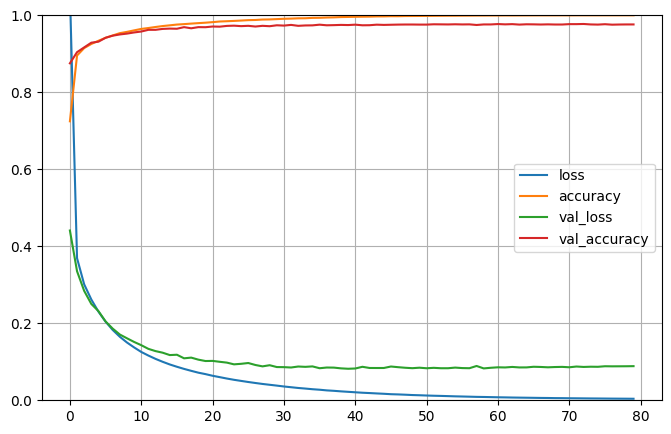

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 300)               235500    
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/80
1594/1594 [==============================] - 5s 3ms/step - loss: 0.6131 - accuracy: 0.8447 - val_loss: 0.3316 - val_accuracy: 0.9014
Epoch 

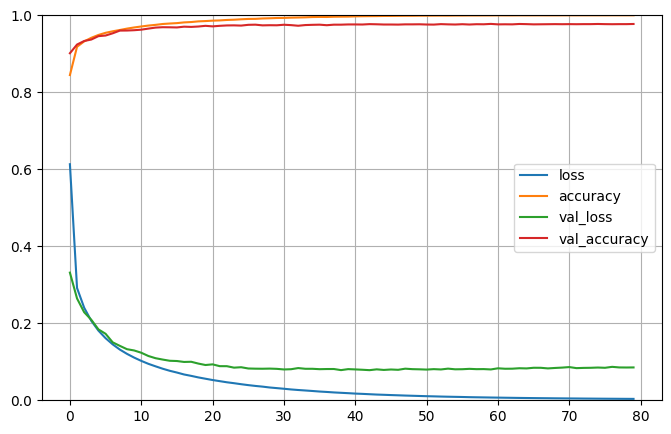

In [2]:
X_train_full, y_train_full, X_test, y_test = load_data()

X_valid, X_train, y_valid, y_train, X_test = data_normalization(X_train_full, y_train_full, X_test)     # data_normalization

# Random Normal
model, history = makemodel(X_train, y_train, X_valid, y_valid, epochs=80, init_way='random_normal', dropout='no')
evalmodel(model, history, X_test, y_test)
print("\n\n============================== [ Random Normal ] ==============================\n\n")
plt.show()

# Xavier Normal
model, history = makemodel(X_train, y_train, X_valid, y_valid, epochs=80, init_way='xavier', dropout='no')
evalmodel(model, history, X_test, y_test)
print("\n\n============================== [ Xavier Normal ] ==============================\n\n")
plt.show()

**결과 (테스트셋 정확도)**: Random Normal 0.9776 vs Xavier 0.9789 — Xavier 쪽이 근소하게 더 높았다.

학습 로그를 보면 Xavier 초기화 쪽이 초반 epoch부터 loss가 더 낮게 시작해서 더 빠르게 안정화되는 경향을 보였다.
두 모델 모두 train accuracy가 0.999 이상까지 올라가고 val accuracy도 0.97대 후반으로 높아서, 과소적합은 아니지만
train accuracy가 거의 100%에 가깝다는 점에서 어느 정도 과적합 여지는 있어 보인다 (다만 val accuracy도 함께 높게 유지됨).

## 2. 실험 2 — 입력 정규화: 0~255 vs 0~1

같은 모델 구조에 입력 픽셀값만 정규화 유무를 다르게 해서 비교한다.

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 300)               235500    
                                                                 
 dense_7 (Dense)             (None, 100)               30100     
                                                                 
 dense_8 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/80
1594/1594 [==============================] - 4s 3ms/step - loss: 196598640.0000 - accuracy: 0.1103 - val_loss: 2.3117 - val_accuracy: 0.109

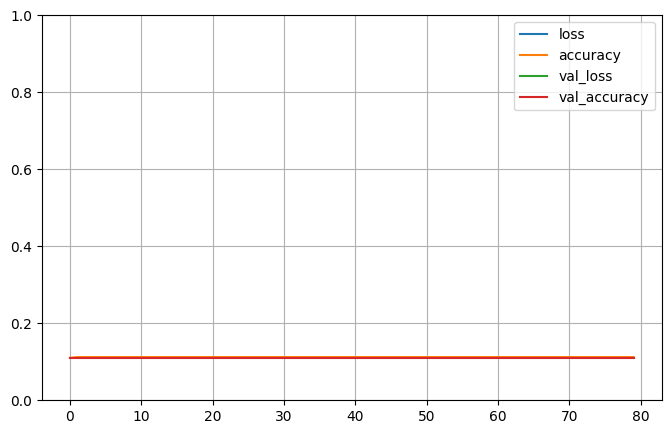

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_9 (Dense)             (None, 300)               235500    
                                                                 
 dense_10 (Dense)            (None, 100)               30100     
                                                                 
 dense_11 (Dense)            (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/80
1594/1594 [==============================] - 5s 3ms/step - loss: 0.6340 - accuracy: 0.8352 - val_loss: 0.3544 - val_accuracy: 0.8984
Epoch 

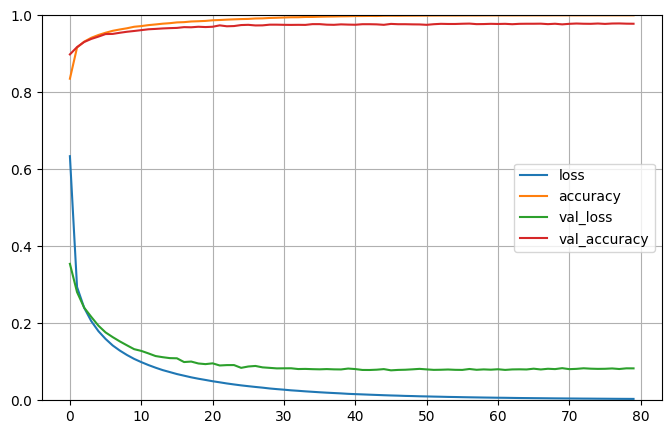

In [3]:
X_train_full, y_train_full, X_test, y_test = load_data()

# 0 ~ 255 각 픽셀값으로 학습
X_valid, X_train, y_valid, y_train, X_test = data_denormalization(X_train_full, y_train_full, X_test)   # data_denormalization
model, history = makemodel(X_train, y_train, X_valid, y_valid, epochs=80, init_way='none', dropout="no")
evalmodel(model, history, X_test, y_test)
print("\n\n============================== [ 0 ~ 255 각 픽셀값으로 학습 ] ==============================\n\n")
plt.show()

# 0 ~ 1 정규화값으로 학습
X_valid, X_train, y_valid, y_train, X_test = data_normalization(X_train_full, y_train_full, X_test)     # data_normalization
model, history = makemodel(X_train, y_train, X_valid, y_valid, epochs=80, init_way='none', dropout='no')
evalmodel(model, history, X_test, y_test)
print("\n\n============================== [ 0 ~ 1 정규화값으로 학습 ] ==============================\n\n")
plt.show()

**결과 (테스트셋 정확도)**: 0~255(정규화 X) 0.1160 vs 0~1(정규화 O) 0.9781 — **차이가 매우 크다.**

정규화하지 않은 모델은 첫 epoch부터 loss가 비정상적으로 크게 튀고(loss 값이 수십억 단위까지 발산), 이후 80 epoch 내내
loss/accuracy가 거의 개선되지 않은 채 정확도 11% 근처(사실상 무작위 수준)에 머물렀다. 입력 스케일이 크면 SGD 학습이
불안정해지고 최적점에 도달하기 어려워진다는 것을 결과로 직접 확인할 수 있었다. 정규화를 거친 모델은 같은 구조·같은
epoch 수로 정확도 97.8%까지 정상적으로 학습됐다.

## 3. 실험 3 — Dropout 적용 여부

정규화된 입력에 Dropout(0.005) 적용 유무만 다르게 해서 비교한다.

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_12 (Dense)            (None, 300)               235500    
                                                                 
 dense_13 (Dense)            (None, 100)               30100     
                                                                 
 dense_14 (Dense)            (None, 10)                1010      
                                                                 
 dropout (Dropout)           (None, 10)                0         
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/80
1594/15

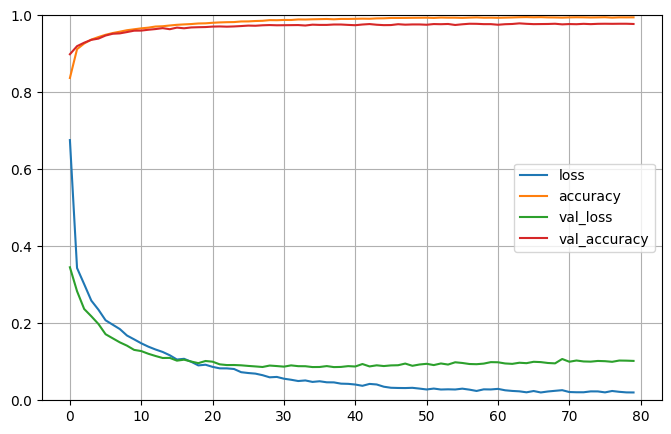

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 784)               0         
                                                                 
 dense_15 (Dense)            (None, 300)               235500    
                                                                 
 dense_16 (Dense)            (None, 100)               30100     
                                                                 
 dense_17 (Dense)            (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/80
1594/1594 [==============================] - 5s 3ms/step - loss: 0.6077 - accuracy: 0.8474 - val_loss: 0.3388 - val_accuracy: 0.9014
Epoch 

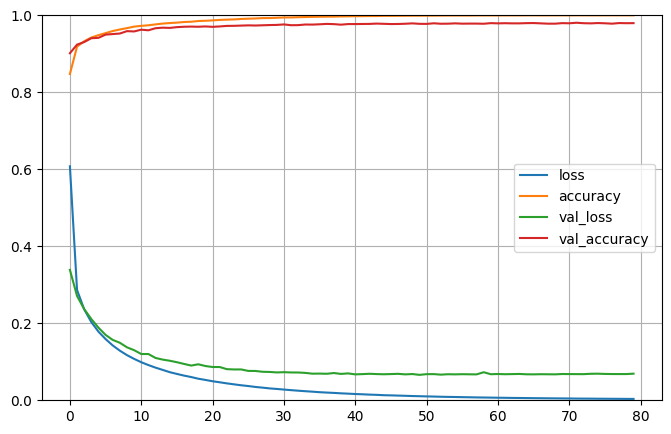

In [4]:
X_train_full, y_train_full, X_test, y_test = load_data()

X_valid, X_train, y_valid, y_train, X_test = data_normalization(X_train_full, y_train_full, X_test)     # data_normalization

# dropout (o)
model, history = makemodel(X_train, y_train, X_valid, y_valid, epochs=80, init_way='none', dropout='yes')
evalmodel(model, history, X_test, y_test)
print("\n\n============================== [ drop out (o) ] ==============================\n\n")
plt.show()

# dropout (x)
model, history = makemodel(X_train, y_train, X_valid, y_valid, epochs=80, init_way='none', dropout='no')
evalmodel(model, history, X_test, y_test)
print("\n\n============================== [ drop out (x) ] ==============================\n\n")
plt.show()



**결과 (테스트셋 정확도)**: Dropout 적용 0.9764 vs 미적용 0.9781 — 이번 실험에서는 Dropout 미적용 쪽이 근소하게 더 높았다.

일반적으로 Dropout은 과적합을 줄이는 데 도움이 되지만, 이 실험에서는 Dropout 비율(0.005)이 매우 작았고
출력층(10-unit) 바로 뒤에만 적용된 구조라 효과가 뚜렷하게 나타나지 않았다. 데이터셋(MNIST)이 비교적 규칙적이고
학습이 쉬운 편이라, 두 모델 모두 val accuracy가 97~98%로 이미 높아서 과적합이 심하지 않았던 것도 차이가 크지 않았던
이유로 보인다.

## 결과 및 배운 점

- **정규화 여부의 영향이 압도적으로 컸다** (정확도 0.12 vs 0.98). 세 실험 중 결과 차이가 가장 극적이었고,
  "왜 입력을 정규화해야 하는가"를 수치로 직접 확인할 수 있었던 실험이었다.
- 가중치 초기화(Random Normal vs Xavier)는 최종 정확도 차이는 크지 않았지만, 학습 초반 loss가 줄어드는 속도에서
  차이가 있었다 — 초기화 방식이 수렴 속도에 영향을 준다는 것을 확인했다.
- Dropout은 이번 설정(작은 비율, 출력층 근처에만 적용)에서는 뚜렷한 개선으로 이어지지 않았다. 정규화 실험만큼 극적인
  차이가 아니었던 만큼, "무조건 특정 기법을 적용한다고 성능이 좋아지는 것은 아니며, 데이터·모델 구조에 따라 효과가
  달라질 수 있다"는 점을 배웠다.
- 같은 모델 구조라도 초기화·정규화·정규화 기법(dropout) 같은 학습 조건 하나하나가 결과에 어떻게 영향을 주는지
  직접 바꿔가며 실험하고 비교하는 과정을 경험했다.
